# **Prototypical Network & resnet18**

In [1]:
import os
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.models import resnet18
from sklearn.model_selection import train_test_split

In [2]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [3]:
# Enable GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


# Data Preparation with Limited Samples

In [4]:
class FewShotDataset(Dataset):
    
    #change the num_episodes from 100 to 50 

    
    def __init__(self, data_dir, n_way=8, k_shot=5, query_shots=5, 
                 transform=None, mode='train', num_episodes=50, test_size=0.2):
        """
        Few-shot learning dataset with limited samples per class
        
        Args:
            data_dir: Path to dataset directory
            n_way: Number of classes per episode (8 for your dataset)
            k_shot: Number of support samples per class (5 for your case)
            query_shots: Number of query samples per class
            transform: Image transformations
            mode: 'train' or 'test'
            num_episodes: Number of episodes to generate
            test_size: Proportion of data to use for testing
        """
        self.data_dir = data_dir
        self.n_way = n_way
        self.k_shot = k_shot
        self.query_shots = query_shots
        self.transform = transform
        self.mode = mode
        self.num_episodes = num_episodes
        
        # Get all class directories
        self.classes = sorted([d for d in os.listdir(data_dir) 
                              if os.path.isdir(os.path.join(data_dir, d))])
        
        if len(self.classes) != 8:
            print(f"Warning: Expected 8 classes, found {len(self.classes)}")
        
        # Split classes into train and test (all classes used in both)
        self.train_classes = self.classes
        self.test_classes = self.classes
        
        # Load and split image paths for each class
        self.class_images = {}
        self.train_images = {}
        self.test_images = {}
        
        for class_name in self.classes:
            class_path = os.path.join(data_dir, class_name)
            images = [os.path.join(class_path, img) for img in os.listdir(class_path) 
                     if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
            
            if len(images) < (k_shot + query_shots):
                print(f"Warning: Class {class_name} has only {len(images)} images, "
                      f"but need at least {k_shot + query_shots}")
            
            # Split images into train and test sets
            train_imgs, test_imgs = train_test_split(
                images, test_size=test_size, random_state=42
            )
            
            self.class_images[class_name] = images
            self.train_images[class_name] = train_imgs
            self.test_images[class_name] = test_imgs
        
        # Create episodes
        self.episodes = self._create_episodes()
    
    def _create_episodes(self):
        """Create few-shot learning episodes"""
        episodes = []
        
        for _ in range(self.num_episodes):
            # Use all 8 classes (since n_way=8)
            selected_classes = self.classes  # Use all 8 classes
            episode = {'classes': selected_classes, 'support': [], 'query': []}
            
            for class_idx, class_name in enumerate(selected_classes):
                # Get the appropriate image set based on mode
                if self.mode == 'train':
                    available_images = self.train_images[class_name]
                else:
                    available_images = self.test_images[class_name]
                
                # Ensure we have enough images
                if len(available_images) < (self.k_shot + self.query_shots):
                    print(f"Warning: Not enough images in {class_name} for {self.mode} mode")
                    continue
                
                # Randomly select K support + query samples
                selected_images = random.sample(available_images, self.k_shot + self.query_shots)
                
                # Add to support set
                for img_path in selected_images[:self.k_shot]:
                    episode['support'].append((img_path, class_idx))
                
                # Add to query set
                for img_path in selected_images[self.k_shot:]:
                    episode['query'].append((img_path, class_idx))
            
            # Only add episode if we have enough samples for all classes
            if len(episode['support']) == self.n_way * self.k_shot:
                # Shuffle support and query sets
                random.shuffle(episode['support'])
                random.shuffle(episode['query'])
                episodes.append(episode)
        
        return episodes
    
    def __len__(self):
        return len(self.episodes)
    
    def __getitem__(self, idx):
        """Get a complete episode (support + query sets)"""
        episode = self.episodes[idx]
        
        # Load support set
        support_images, support_labels = [], []
        for img_path, label in episode['support']:
            img = Image.open(img_path).convert('RGB')
            if self.transform:
                img = self.transform(img)
            support_images.append(img)
            support_labels.append(label)
        
        # Load query set
        query_images, query_labels = [], []
        for img_path, label in episode['query']:
            img = Image.open(img_path).convert('RGB')
            if self.transform:
                img = self.transform(img)
            query_images.append(img)
            query_labels.append(label)
        
        return (torch.stack(support_images), torch.tensor(support_labels),
                torch.stack(query_images), torch.tensor(query_labels))

# Enhanced Prototypical Network Model

In [5]:
class EnhancedPrototypicalNetwork(nn.Module):
    def __init__(self, feature_dim=256, use_pretrained=True):
        """
        Enhanced Prototypical Network with better feature extraction
        
        Args:
            feature_dim: Dimension of output feature vectors
            use_pretrained: Whether to use pretrained ResNet weights
        """
        super(EnhancedPrototypicalNetwork, self).__init__()
        
        # Use ResNet-18 as backbone
        self.backbone = resnet18(pretrained=use_pretrained)
        
        # Remove the final classification layer
        self.feature_extractor = nn.Sequential(
            *list(self.backbone.children())[:-1],  # Remove final layer
            nn.Flatten()
        )
        
        # Get the output dimension of the backbone
        with torch.no_grad():
            dummy_input = torch.randn(1, 3, 224, 224)
            backbone_output = self.feature_extractor(dummy_input)
            backbone_dim = backbone_output.shape[1]
        
        # Enhanced projection network
        self.projection = nn.Sequential(
            nn.Linear(backbone_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, feature_dim),
            nn.BatchNorm1d(feature_dim),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        
        # Distance metric (Euclidean by default)
        self.distance_metric = 'euclidean'
    
    def forward(self, x):
        """Extract features from input images"""
        features = self.feature_extractor(x)
        return self.projection(features)
    
    def compute_prototypes(self, support_features, support_labels):
        """Compute class prototypes from support set features"""
        prototypes = []
        unique_labels = torch.unique(support_labels)
        
        for class_label in unique_labels:
            # Get features for this class
            class_mask = (support_labels == class_label)
            class_features = support_features[class_mask]
            # Compute mean prototype
            prototype = class_features.mean(dim=0)
            prototypes.append(prototype)
        
        return torch.stack(prototypes)
    
    def compute_distances(self, query_features, prototypes):
        """Compute distances between query features and prototypes"""
        if self.distance_metric == 'euclidean':
            # Euclidean distance
            distances = torch.cdist(query_features.unsqueeze(0), prototypes.unsqueeze(0))[0]
        elif self.distance_metric == 'cosine':
            # Cosine similarity (convert to distance)
            query_norm = F.normalize(query_features, p=2, dim=1)
            proto_norm = F.normalize(prototypes, p=2, dim=1)
            similarities = torch.mm(query_norm, proto_norm.t())
            distances = 1 - similarities
        else:
            raise ValueError(f"Unknown distance metric: {self.distance_metric}")
        
        return distances
    
    def predict(self, query_features, prototypes):
        """Predict query samples using distance to prototypes"""
        distances = self.compute_distances(query_features, prototypes)
        # Convert distances to probabilities (softmax over negative distances)
        return F.softmax(-distances, dim=1)

# Training Setup with 5-Shot Learning

In [6]:
# Data transformations with strong augmentation for few-shot learning
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets
data_dir = "/kaggle/input/cucumber-dataset/Original Image"  # Change this to your dataset path

print("Creating datasets...")
train_dataset = FewShotDataset(
    data_dir=data_dir,
    n_way=8,           # Use all 8 classes
    k_shot=5,          # 5 support samples per class (as requested)
    query_shots=5,     # 5 query samples per class
    transform=train_transform,
    mode='train',

    #reduce num_episodes from 200 to 100
    
    num_episodes=100,  # Number of training episodes
    test_size=0.2      # 20% of data for testing
)

test_dataset = FewShotDataset(
    data_dir=data_dir,
    n_way=8,
    k_shot=5,
    query_shots=5,
    transform=test_transform,
    mode='test',

    #reduce num_epsiodes from 50 to 25
    
    num_episodes=25,   # Number of test episodes
    test_size=0.2
)

print(f"Training episodes: {len(train_dataset)}")
print(f"Test episodes: {len(test_dataset)}")

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=2)

Creating datasets...
Training episodes: 100
Test episodes: 25


# Training Function with Validation

In [7]:
def train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs=30):
    """Train the prototypical network with validation"""
    model.train()
    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []
    
    best_val_accuracy = 0.0
    patience_counter = 0
    patience = 5  # Early stopping patience
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        epoch_train_loss = 0.0
        epoch_train_accuracy = 0.0
        num_train_episodes = 0
        
        for support_imgs, support_labels, query_imgs, query_labels in train_loader:
            # Move data to device
            support_imgs = support_imgs.squeeze(0).to(device)
            support_labels = support_labels.squeeze(0).to(device)
            query_imgs = query_imgs.squeeze(0).to(device)
            query_labels = query_labels.squeeze(0).to(device)
            
            # Zero gradients
            optimizer.zero_grad()
            
            # Extract features
            support_features = model(support_imgs)
            query_features = model(query_imgs)
            
            # Compute prototypes
            prototypes = model.compute_prototypes(support_features, support_labels)
            
            # Predict query samples
            predictions = model.predict(query_features, prototypes)
            
            # Calculate loss
            loss = criterion(predictions, query_labels)
            
            # Calculate accuracy
            _, predicted = torch.max(predictions, 1)
            accuracy = (predicted == query_labels).float().mean()
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            epoch_train_loss += loss.item()
            epoch_train_accuracy += accuracy.item()
            num_train_episodes += 1
        
        # Validation phase
        model.eval()
        epoch_val_loss = 0.0
        epoch_val_accuracy = 0.0
        num_val_episodes = 0
        
        with torch.no_grad():
            for support_imgs, support_labels, query_imgs, query_labels in val_loader:
                support_imgs = support_imgs.squeeze(0).to(device)
                support_labels = support_labels.squeeze(0).to(device)
                query_imgs = query_imgs.squeeze(0).to(device)
                query_labels = query_labels.squeeze(0).to(device)
                
                support_features = model(support_imgs)
                query_features = model(query_imgs)
                prototypes = model.compute_prototypes(support_features, support_labels)
                predictions = model.predict(query_features, prototypes)
                
                loss = criterion(predictions, query_labels)
                _, predicted = torch.max(predictions, 1)
                accuracy = (predicted == query_labels).float().mean()
                
                epoch_val_loss += loss.item()
                epoch_val_accuracy += accuracy.item()
                num_val_episodes += 1
        
        # Calculate epoch statistics
        avg_train_loss = epoch_train_loss / num_train_episodes
        avg_train_accuracy = epoch_train_accuracy / num_train_episodes
        avg_val_loss = epoch_val_loss / num_val_episodes
        avg_val_accuracy = epoch_val_accuracy / num_val_episodes
        
        train_losses.append(avg_train_loss)
        train_accuracies.append(avg_train_accuracy)
        val_losses.append(avg_val_loss)
        val_accuracies.append(avg_val_accuracy)
        
        print(f'Epoch [{epoch+1}/{num_epochs}]')
        print(f'Train - Loss: {avg_train_loss:.4f}, Accuracy: {avg_train_accuracy:.4f}')
        print(f'Val   - Loss: {avg_val_loss:.4f}, Accuracy: {avg_val_accuracy:.4f}')
        print('-' * 50)
        
        # Early stopping check
        if avg_val_accuracy > best_val_accuracy:
            best_val_accuracy = avg_val_accuracy
            patience_counter = 0
            # Save best model
            torch.save(model.state_dict(), '/kaggle/working/best_prototypical_model.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
    
    return train_losses, train_accuracies, val_losses, val_accuracies

# Main Training Execution

In [8]:
# Initialize model, optimizer, and loss function
print("Initializing model...")
model = EnhancedPrototypicalNetwork(feature_dim=256, use_pretrained=True).to(device)

# Use Adam optimizer with weight decay
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3, verbose=True
)

criterion = nn.CrossEntropyLoss()

# Create a validation loader (using 20% of training episodes for validation)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = torch.utils.data.random_split(
    train_dataset, [train_size, val_size], 
    generator=torch.Generator().manual_seed(42)
)

train_loader_sub = DataLoader(train_subset, batch_size=1, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=1, shuffle=False)

# Train the model
print("Starting training...")
train_losses, train_accuracies, val_losses, val_accuracies = train_model(

    #num_epochs changes from 30 to 14
    
    model, train_loader_sub, val_loader, optimizer, criterion, num_epochs=15
)

# Load best model
model.load_state_dict(torch.load('/kaggle/working/best_prototypical_model.pth'))
print("Loaded best model for evaluation")

Initializing model...


/usr/local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 207MB/s]
/usr/local/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(

Starting training...
Epoch [1/15]
Train - Loss: 1.5913, Accuracy: 0.7887
Val   - Loss: 1.3535, Accuracy: 0.9300
--------------------------------------------------
Epoch [2/15]
Train - Loss: 1.3421, Accuracy: 0.9528
Val   - Loss: 1.3172, Accuracy: 0.9588
--------------------------------------------------
Epoch [3/15]
Train - Loss: 1.3045, Accuracy: 0.9834
Val   - Loss: 1.2948, Accuracy: 0.9838
--------------------------------------------------
Epoch [4/15]
Train - Loss: 1.2926, Accuracy: 0.9900
Val   - Loss: 1.2964, Accuracy: 0.9775
--------------------------------------------------
Epoch [5/15]
Train - Loss: 1.2871, Accuracy: 0.9922
Val   - Loss: 1.2809, Accuracy: 0.9950
--------------------------------------------------
Epoch [6/15]
Train - Loss: 1.2842, Accuracy: 0.9938
Val   - Loss: 1.2853, Accuracy: 0.9888
--------------------------------------------------
Epoch [7/15]
Train - Loss: 1.2834, Accuracy: 0.9941
Val   - Loss: 1.2844, Accuracy: 0.9925
------------------------------------

# Comprehensive Evaluation


Running comprehensive evaluation...
Overall Test Accuracy: 0.8830 ± 0.0462

Per-class Accuracy:
  Class 0: 0.6480
  Class 1: 1.0000
  Class 2: 0.9280
  Class 3: 0.8880
  Class 4: 0.9440
  Class 5: 0.8640
  Class 6: 0.7920
  Class 7: 1.0000


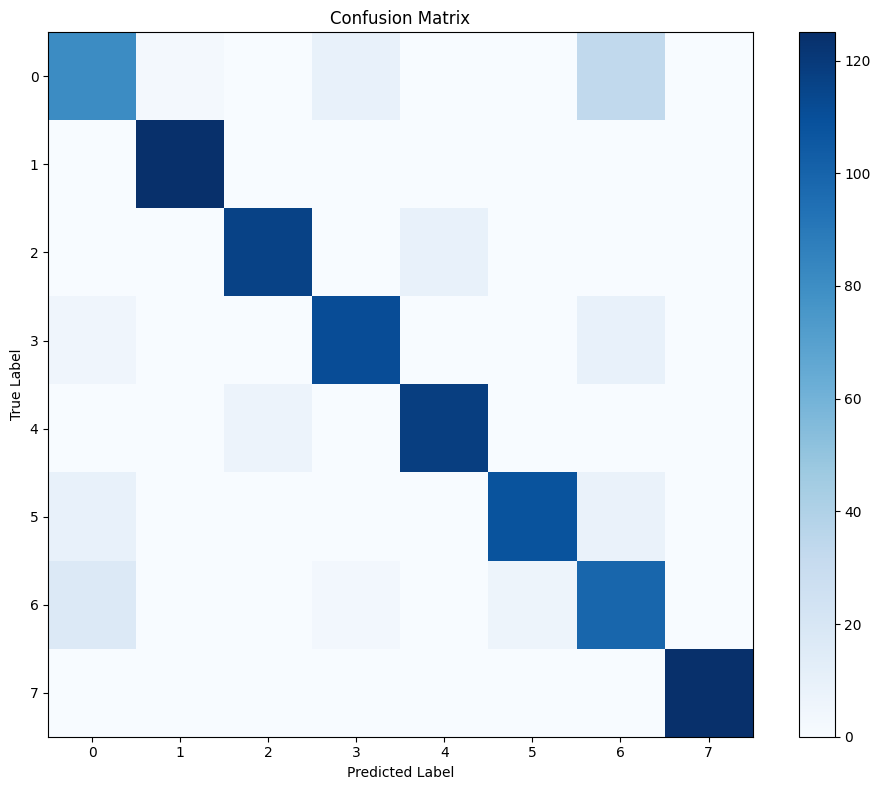

In [9]:
def comprehensive_evaluation(model, test_loader):
    """Comprehensive evaluation with detailed metrics"""
    model.eval()
    all_accuracies = []
    confusion_matrix = np.zeros((8, 8), dtype=int)  # 8x8 confusion matrix
    
    with torch.no_grad():
        for support_imgs, support_labels, query_imgs, query_labels in test_loader:
            support_imgs = support_imgs.squeeze(0).to(device)
            support_labels = support_labels.squeeze(0).to(device)
            query_imgs = query_imgs.squeeze(0).to(device)
            query_labels = query_labels.squeeze(0).to(device)
            
            support_features = model(support_imgs)
            query_features = model(query_imgs)
            prototypes = model.compute_prototypes(support_features, support_labels)
            predictions = model.predict(query_features, prototypes)
            
            _, predicted = torch.max(predictions, 1)
            accuracy = (predicted == query_labels).float().mean()
            all_accuracies.append(accuracy.item())
            
            # Update confusion matrix
            for true, pred in zip(query_labels.cpu().numpy(), predicted.cpu().numpy()):
                confusion_matrix[true, pred] += 1
    
    # Calculate metrics
    mean_accuracy = np.mean(all_accuracies)
    std_accuracy = np.std(all_accuracies)
    
    # Calculate per-class accuracy
    class_accuracy = np.diag(confusion_matrix) / np.sum(confusion_matrix, axis=1)
    
    print(f'Overall Test Accuracy: {mean_accuracy:.4f} ± {std_accuracy:.4f}')
    print('\nPer-class Accuracy:')
    for i, acc in enumerate(class_accuracy):
        print(f'  Class {i}: {acc:.4f}')
    
    return all_accuracies, confusion_matrix

# Run comprehensive evaluation
print("\nRunning comprehensive evaluation...")
test_accuracies, confusion_matrix = comprehensive_evaluation(model, test_loader)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
plt.imshow(confusion_matrix, cmap='Blues', interpolation='nearest')
plt.colorbar()
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png')
plt.show()

# Visualization and Analysis

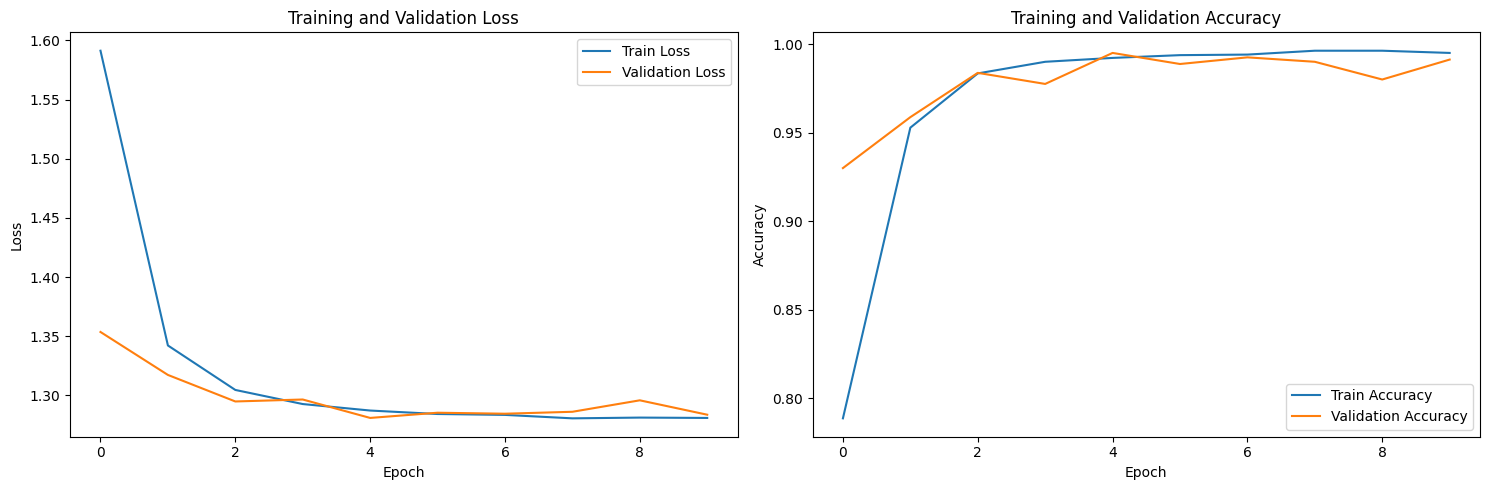

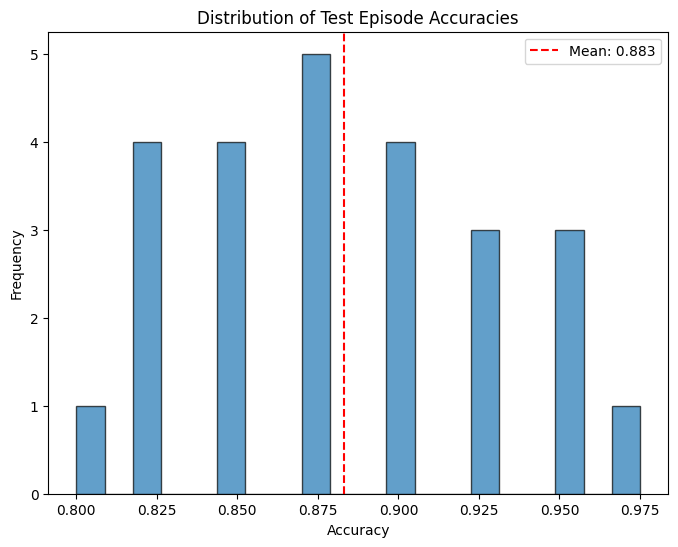


Final Results:
Mean Test Accuracy: 0.8830
Std Test Accuracy: 0.0462
Minimum Accuracy: 0.8000
Maximum Accuracy: 0.9750


In [10]:
# Plot training history
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig('/kaggle/working/training_history.png')
plt.show()

# Test accuracy distribution
plt.figure(figsize=(8, 6))
plt.hist(test_accuracies, bins=20, alpha=0.7, edgecolor='black')
plt.title('Distribution of Test Episode Accuracies')
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.axvline(np.mean(test_accuracies), color='red', linestyle='--', 
            label=f'Mean: {np.mean(test_accuracies):.3f}')
plt.legend()
plt.savefig('/kaggle/working/accuracy_distribution.png')
plt.show()

print(f"\nFinal Results:")
print(f"Mean Test Accuracy: {np.mean(test_accuracies):.4f}")
print(f"Std Test Accuracy: {np.std(test_accuracies):.4f}")
print(f"Minimum Accuracy: {np.min(test_accuracies):.4f}")
print(f"Maximum Accuracy: {np.max(test_accuracies):.4f}")